# Burger king Menu Pricing & Value Analysis

## Objective
The purpose of this analysis is to evaluate menu pricing strategies, identify high-value items, and uncover patterns in nutritional efficiency across products.



In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
import warnings
from dotenv import load_dotenv
load_dotenv()
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

In [2]:
url = os.getenv('URL')
engine = create_engine(url)

In [3]:
df = pd.read_sql("SELECT * FROM bg_king_clean;", engine)
df.head()

,STORE_ID,CITY,STATE,ZIP,MENU_SECTION,MENU_ITEM_NAME,MENU_ITEM_DESCRIPTION,CALORIES,MENU_PRICE,QUARTER,Month
0,13165,Houston,TX,77039,Condiments,Zesty Dipping Sauce,None,150,0.25,2025Q4,November
1,13165,Houston,TX,77039,Breakfast Digital Exclusives,Get Going Trio,"Burrito Jr, Small Hot Coffee, and 3Pc French T...",760,5.00,2025Q4,November
2,13165,Houston,TX,77039,Drinks & Coffee,Chocolate OreoÂ® Shake,"Creamy, vanilla soft serve mixed with OREOÂ® c...",670,0.85,2025Q4,November
3,7560,Sturtevant,WI,53177,Breakfast Meals,5 Pc. French Toast Sticks with Syrup Meal Large,"Sweet, golden brown, and piping hot, our five-...",1200,7.79,2025Q4,November
4,7560,Sturtevant,WI,53177,Breakfast Sides,Medium French Fries,Piping hot and perfectly salted.,370,3.59,2025Q4,November


In [4]:
print("Rows:", df.shape[0],'\n')
print("Columns:", df.shape[1],'\n')
print("Duplicate rows:", df.duplicated().sum(),'\n')
print("Missing values:\n", df.isnull().sum())

Rows: 35268 

Columns: 11 

Duplicate rows: 0 

Missing values:
 STORE_ID                    0
CITY                        0
STATE                       0
ZIP                         0
MENU_SECTION                0
MENU_ITEM_NAME              0
MENU_ITEM_DESCRIPTION    1359
CALORIES                    0
MENU_PRICE                  0
QUARTER                     0
Month                       0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35268 entries, 0 to 35267
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   STORE_ID               35268 non-null  int64  
 1   CITY                   35268 non-null  object 
 2   STATE                  35268 non-null  object 
 3   ZIP                    35268 non-null  int64  
 4   MENU_SECTION           35268 non-null  object 
 5   MENU_ITEM_NAME         35268 non-null  object 
 6   MENU_ITEM_DESCRIPTION  33909 non-null  object 
 7   CALORIES               35268 non-null  int64  
 8   MENU_PRICE             35268 non-null  float64
 9   QUARTER                35268 non-null  object 
 10  Month                  35268 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 3.0+ MB


In [6]:
for col in df.columns:
    print(col)

STORE_ID
CITY
STATE
ZIP
MENU_SECTION
MENU_ITEM_NAME
MENU_ITEM_DESCRIPTION
CALORIES
MENU_PRICE
QUARTER
Month


In [7]:
df.describe()

,STORE_ID,ZIP,CALORIES,MENU_PRICE
count,35268.00000,35268.000000,35268.000000,35268.000000
mean,12106.18711,67377.511512,821.919417,6.192294
std,9611.98224,21190.005740,588.821863,4.282803
min,266.00000,18301.000000,0.000000,0.010000
25%,3335.00000,53177.000000,320.000000,2.490000
50%,11829.00000,77039.000000,750.000000,5.990000
75%,13165.00000,79928.000000,1260.000000,9.450000
max,28777.00000,98375.000000,5440.000000,32.990000


## Which menu sections dominate the product catalog?

Burger King's menu is concentrated around Meals, Burgers, and Drinks, indicating a focused product strategy rather than a highly diversified one.

Higher-priced items such as meals and burgers likely drive revenue, while lower-priced drinks help increase total order value through add-on purchases.

Overall, the menu appears structured to balance revenue generation with customer affordability.

In [8]:
menu_section = df.groupby('MENU_SECTION')['MENU_ITEM_NAME'].nunique().sort_values(ascending= False)

menu_section_pct = (menu_section/df['MENU_ITEM_NAME'].nunique())*100

menu_section_pct = menu_section_pct.round(2)

menu_section_pct

MENU_SECTION
Meals                           26.91
Flame Grilled Burgers           26.16
Drinks & Coffee                 24.81
Limited Time Only               18.09
Burgers for Breakfast           15.70
Chicken & Fish                  14.80
Sides                           13.00
Breakfast Meals                  8.97
Monster Menu                     5.53
Whopper by You                   4.78
Breakfast Sides                  4.33
Breakfast Sandwiches             3.89
Digital Exclusives               2.54
Sweets                           2.39
NEEDED FOR PAR                   1.64
King Jr. Kids Meals              0.90
Condiments                       0.90
Breakfast Digital Exclusives     0.60
Burritos                         0.30
Name: MENU_ITEM_NAME, dtype: float64

In [9]:
df.groupby('MENU_SECTION')['MENU_PRICE'].median().sort_values(ascending=False)

MENU_SECTION
Whopper by You                  10.040
Digital Exclusives               9.990
Meals                            9.990
Burgers for Breakfast            8.990
Flame Grilled Burgers            8.790
Monster Menu                     7.990
Breakfast Meals                  7.790
Chicken & Fish                   6.990
Breakfast Digital Exclusives     6.495
King Jr. Kids Meals              4.690
Breakfast Sandwiches             4.590
Sides                            3.290
Burritos                         2.890
Breakfast Sides                  2.740
Limited Time Only                2.690
NEEDED FOR PAR                   1.890
Drinks & Coffee                  1.790
Sweets                           1.700
Condiments                       0.300
Name: MENU_PRICE, dtype: float64

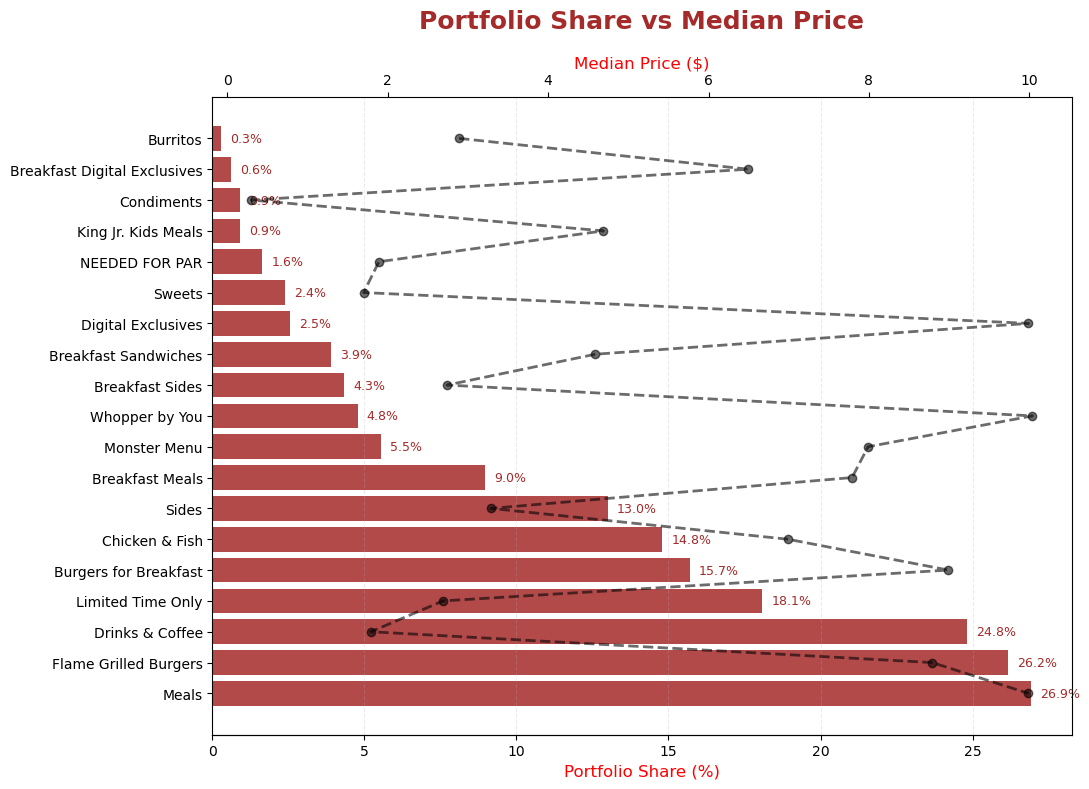

In [10]:


# Prepare data
share = menu_section_pct.sort_values(ascending=True)
median_price = df.groupby('MENU_SECTION')['MENU_PRICE'].median().loc[share.index]

plt.figure(figsize=(11,8))

ax1 = plt.gca()

# Portfolio share bars
bars = ax1.barh(
    share.index,
    share.values,
    color='brown',
    alpha=0.85
)

ax1.set_xlabel("Portfolio Share (%)", fontsize=12,color = 'red')
ax1.invert_yaxis()

# Remove clutter
for spine in ['top','right','left']:
    ax1.spines[spine].set_visible(False)

ax1.grid(axis='x', linestyle='--', alpha=0.25)

# SECOND AXIS
ax2 = ax1.twiny()

ax2.plot(
    median_price.values,
    share.index,
    color='black',
    marker='o',
    linewidth=2,
    linestyle = '--',
    alpha = 0.58
    
)

ax2.set_xlabel("Median Price ($)", fontsize=12,color = 'red')

# Labels on bars
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%",
             va='center',
             fontsize=9,
            color = 'brown')

plt.title("Portfolio Share vs Median Price",
          fontsize=18,
          weight='bold',
          color = 'brown',
          pad=20)

plt.tight_layout()
plt.show()


## Did the menu change between quarters — were items added, removed, or repositioned?

The menu remained largely stable, but item additions and removals indicate ongoing optimization. Most new products appeared in core revenue categories like burgers and meals, suggesting a targeted approach to strengthening high-performing segments.

In [11]:
df.groupby('QUARTER')['MENU_ITEM_NAME'].nunique()

QUARTER
2025Q4    598
2026Q1    586
Name: MENU_ITEM_NAME, dtype: int64

In [12]:
q4_items = set(df[df['QUARTER']=="2025Q4"]['MENU_ITEM_NAME'])
q1_items = set(df[df['QUARTER']=="2026Q1"]['MENU_ITEM_NAME'])

added_items = q1_items - q4_items
removed_items = q4_items - q1_items

len(added_items), len(removed_items)

(71, 83)

In [13]:
df[df['MENU_ITEM_NAME'].isin(added_items)].groupby(['MENU_SECTION'])['MENU_ITEM_NAME'].nunique().sort_values(ascending = False)

MENU_SECTION
Flame Grilled Burgers    35
Meals                    34
Limited Time Only        29
Whopper by You           18
Chicken & Fish           11
Burgers for Breakfast     9
Drinks & Coffee           7
Breakfast Meals           4
Breakfast Sides           4
Sides                     4
Digital Exclusives        3
Sweets                    3
Name: MENU_ITEM_NAME, dtype: int64

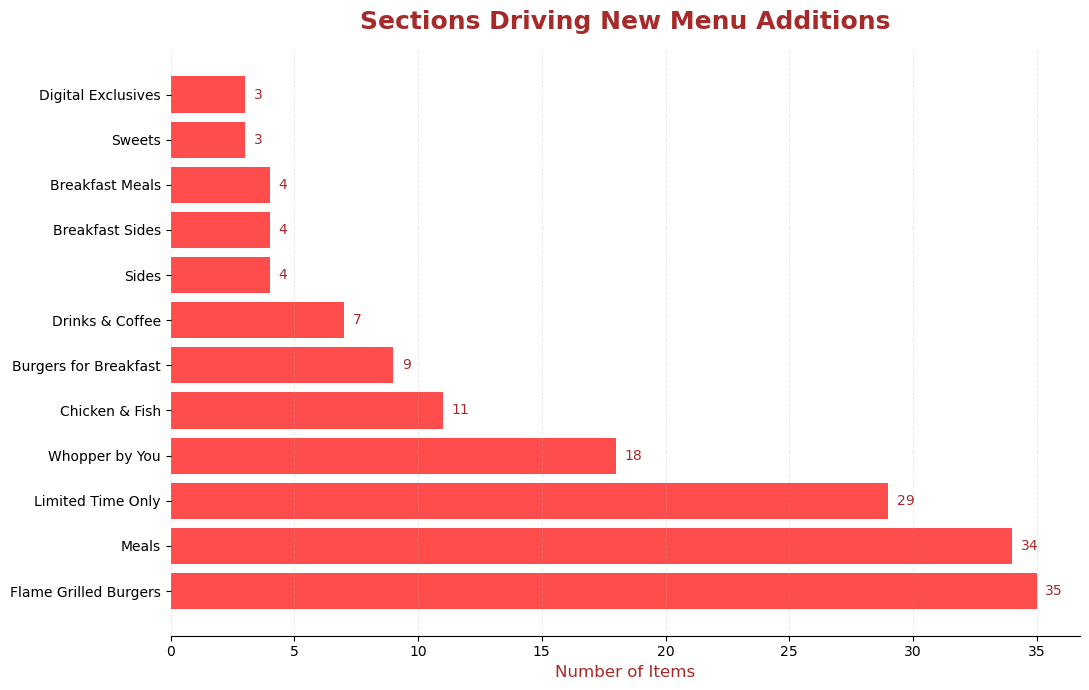

In [14]:
added_section = df[df['MENU_ITEM_NAME'].isin(added_items)] \
                .groupby('MENU_SECTION')['MENU_ITEM_NAME'] \
                .nunique() \
                .sort_values()

fig, ax = plt.subplots(figsize=(11,7))

bars = ax.barh(
    added_section.index,
    added_section.values,
    color='r',
    alpha = 0.7
)


ax.invert_yaxis()


for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.25)

ax.set_title("Sections Driving New Menu Additions",
             fontsize=18,
             weight='bold',
             color = 'brown',
            pad = 15)

ax.set_xlabel("Number of Items", fontsize=12,color = 'brown')

# Value labels (VERY important)
offset = added_section.max() * 0.01

for bar in bars:
    width = bar.get_width()
    ax.text(width + offset,
            bar.get_y() + bar.get_height()/2,
            int(width),
            va='center',
            fontsize=10,
           color = 'brown')

plt.tight_layout()
plt.show()


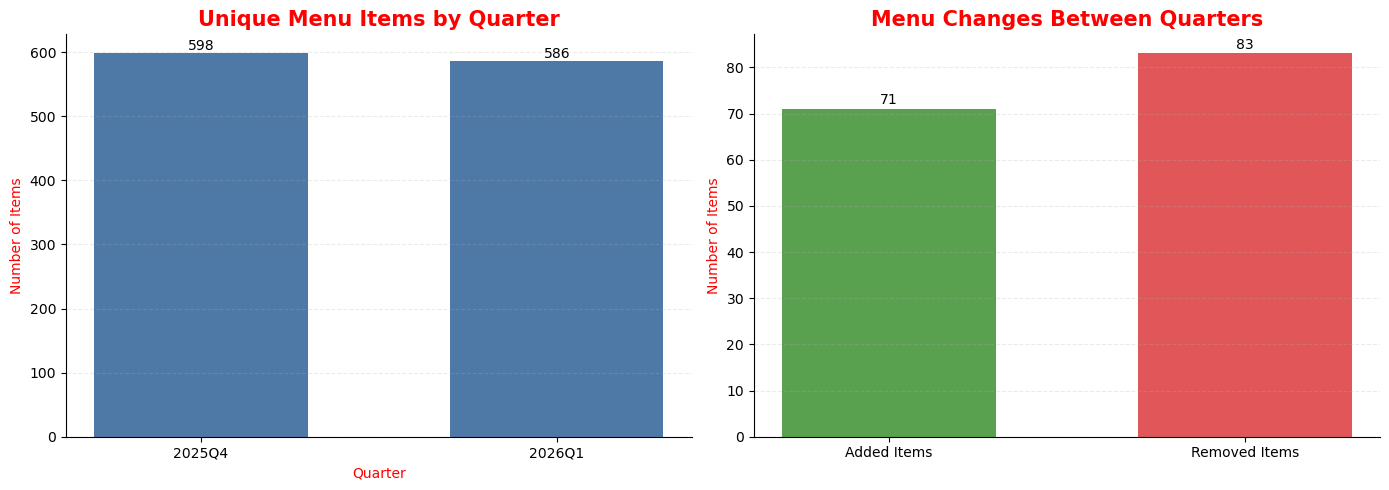

In [15]:
quarter_counts = df.groupby('QUARTER')['MENU_ITEM_NAME'].nunique()

change_counts = [len(added_items), len(removed_items)]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -------- Chart 1: Unique Items ----------
ax1 = axes[0]

bars1 = ax1.bar(
    quarter_counts.index,
    quarter_counts.values,
    color='#4E79A7',
    width=0.6
)

ax1.set_title("Unique Menu Items by Quarter",
              fontsize=15,
              color = 'r',
              weight='bold')

ax1.set_xlabel("Quarter",color='r')
ax1.set_ylabel("Number of Items",color='r')

ax1.grid(axis='y', linestyle='--', alpha=0.25)

for spine in ['top','right']:
    ax1.spines[spine].set_visible(False)

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        int(height),
        ha='center'
    )


# -------- Chart 2: Added vs Removed ----------
ax2 = axes[1]

colors = ['#59A14F', '#E15759']

bars2 = ax2.bar(
    ['Added Items','Removed Items'],
    change_counts,
    color=colors,
    width=0.6
)

ax2.set_title("Menu Changes Between Quarters",
              fontsize=15,
              color= 'red',
              weight='bold')

ax2.set_ylabel("Number of Items",color = 'r')

ax2.grid(axis='y', linestyle='--', alpha=0.25)

for spine in ['top','right']:
    ax2.spines[spine].set_visible(False)

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        int(height),
        ha='center'
    )

plt.tight_layout()
plt.show()


## Are identical menu items priced consistently across different stores?

Price variation remained very stable across both quarters. The median price difference increased slightly from $2.20 in Q4 to $2.39 in Q1 — a change of about $0.19 (~9%), indicating no major shift in pricing strategy.

Additionally, 75% of menu items showed price differences below roughly $3.25 in Q1 and $3.12 in Q4, confirming that most stores operate within a narrow pricing range.

Overall, this consistency suggests that Burger King follows a controlled pricing approach, allowing small local adjustments while maintaining strong network-wide price alignment.

In [16]:
# --------------------------------------quarter 1 of 2026--------------------------------------------------
q1_df = df[df['QUARTER'] == '2026Q1']

core_items_q1 = (
    q1_df.groupby('MENU_ITEM_NAME')['STORE_ID']
    .nunique()
)

core_items_q1 = core_items_q1[
    core_items_q1 == q1_df['STORE_ID'].nunique()
].index

core_df_q1 = q1_df[q1_df['MENU_ITEM_NAME'].isin(core_items_q1)]

store_item_price_q1 = (
    core_df_q1
    .groupby(['STORE_ID','MENU_ITEM_NAME'])['MENU_PRICE']
    .median()
    .reset_index()
)

price_variation_q1 = (
    store_item_price_q1
    .groupby('MENU_ITEM_NAME')['MENU_PRICE']
    .agg(['min','max','median'])
)

price_variation_q1['diff'] = price_variation_q1['max'] - price_variation_q1['min']

price_variation_q1['diff'].describe()

count    320.000000
mean       2.697922
std        2.181341
min        0.000000
25%        1.300000
50%        2.395000
75%        3.252500
max       12.080000
Name: diff, dtype: float64

In [17]:
# --------------------------------------quarter 4 of 2025--------------------------------------------------
q4_df = df[df['QUARTER'] == '2025Q4']

core_items_q4 = (
    q4_df.groupby('MENU_ITEM_NAME')['STORE_ID']
    .nunique()
)

core_items_q4 = core_items_q4[
    core_items_q4 == q4_df['STORE_ID'].nunique()
].index

core_df_q4 = q4_df[q4_df['MENU_ITEM_NAME'].isin(core_items_q4)]

store_item_price_q4 = (
    core_df_q4
    .groupby(['STORE_ID','MENU_ITEM_NAME'])['MENU_PRICE']
    .median()
    .reset_index()
)

price_variation_q4 = (
    store_item_price_q4
    .groupby('MENU_ITEM_NAME')['MENU_PRICE']
    .agg(['min','max','median'])
)

price_variation_q4['diff'] = price_variation_q4['max'] - price_variation_q4['min']

price_variation_q4['diff'].describe()

count    327.000000
mean       2.555153
std        2.083245
min        0.000000
25%        1.185000
50%        2.200000
75%        3.125000
max       12.130000
Name: diff, dtype: float64

In [18]:
qua_diff_prt = (abs(price_variation_q4['diff'].median()-price_variation_q1['diff'].median())/price_variation_q4['diff'].median())*100

In [19]:
qua_diff_prt

8.863636363636312

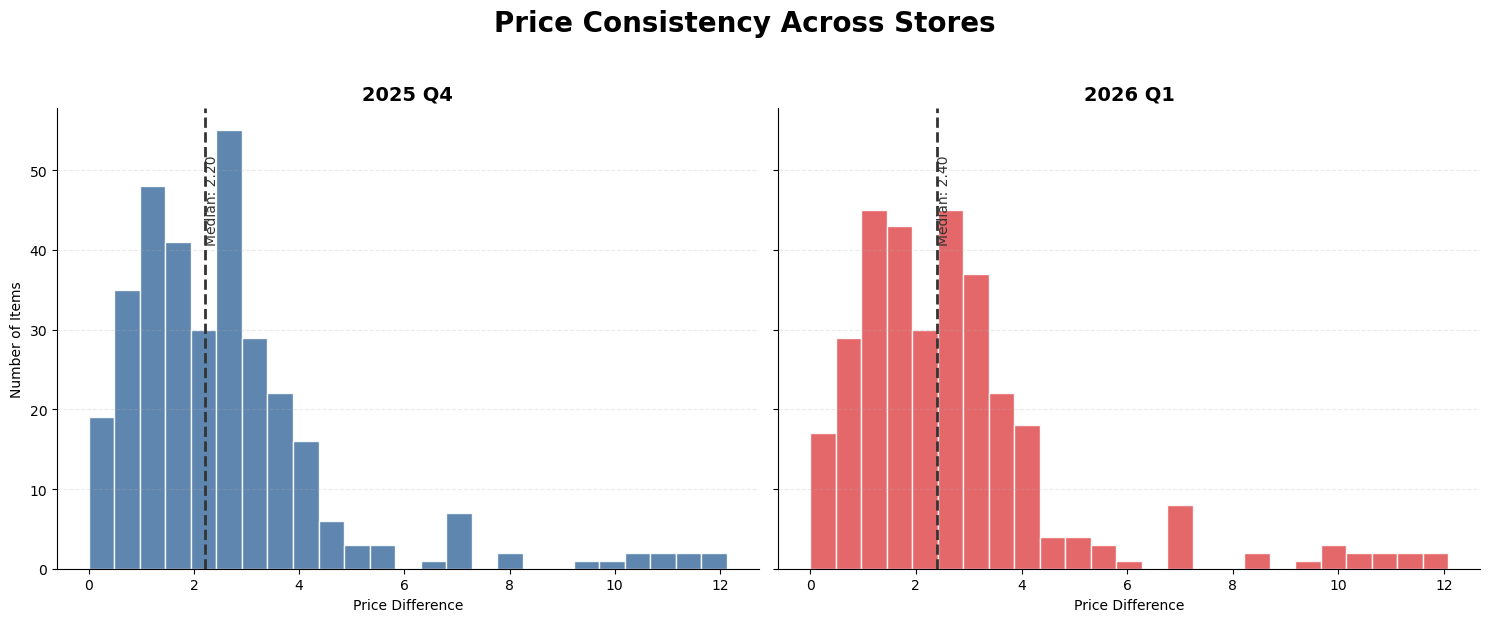

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True)

colors = ['#4E79A7', '#E15759']
datasets = [price_variation_q4['diff'], price_variation_q1['diff']]
titles = ["2025 Q4", "2026 Q1"]

for ax, data, color, title in zip(axes, datasets, colors, titles):
    
    ax.hist(
        data,
        bins=25,
        color=color,
        edgecolor='white',
        alpha=0.9
    )
    
    median_val = data.median()
    
    ax.axvline(
        median_val,
        linestyle='--',
        linewidth=2,
        color='#333333'
    )
    
    ax.text(
        median_val,
        ax.get_ylim()[1]*0.9,
        f"Median: {median_val:.2f}",
        rotation=90,
        va='top',
        color='#333333'
    )

    # Remove clutter
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', linestyle='--', alpha=0.25)

    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel("Price Difference")

axes[0].set_ylabel("Number of Items")


fig.suptitle(
    "Price Consistency Across Stores",
    fontsize=20,
    weight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()


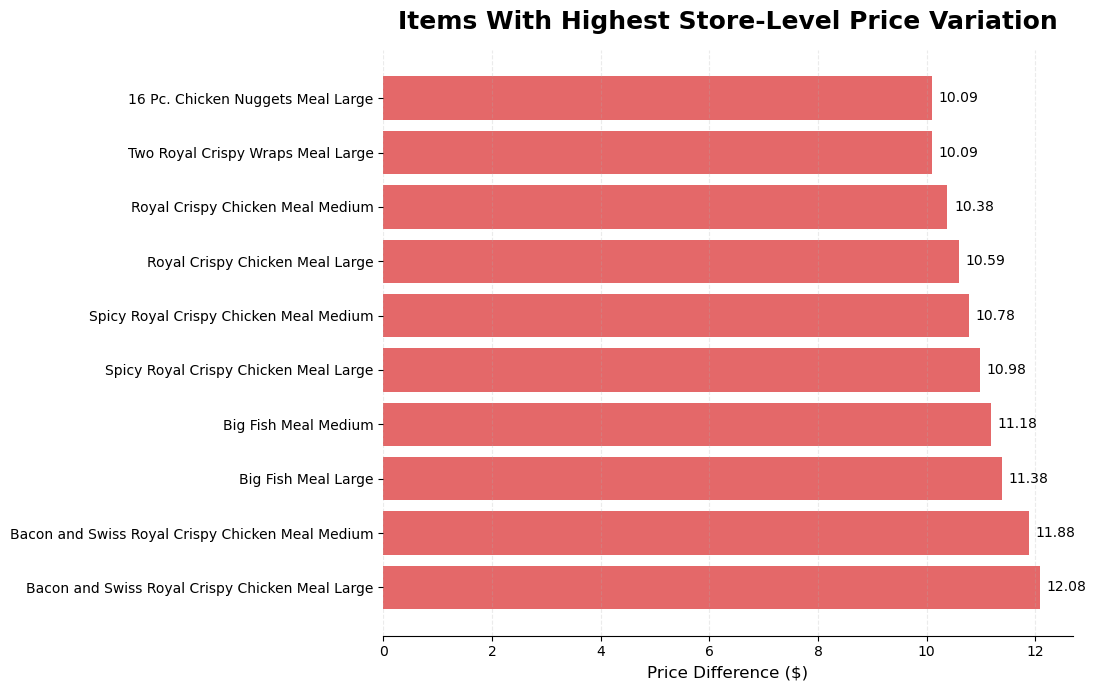

In [21]:
fig, ax = plt.subplots(figsize=(11,7))

top_variation = price_variation_q1['diff'].sort_values(ascending=False).head(10)
data = top_variation.sort_values()

bars = ax.barh(
    data.index,
    data.values,
    color='#E15759',   
    alpha=0.9
)

ax.invert_yaxis()

# Remove clutter
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.25)

ax.set_title(
    "Items With Highest Store-Level Price Variation",
    fontsize=18,
    weight='bold',
    pad=15
)

ax.set_xlabel("Price Difference ($)", fontsize=12)


offset = data.max() * 0.01

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()


## Which stores price significantly above or below the network median?


Store pricing remained structurally consistent, as the same locations continued to operate at premium levels across both quarters. Store 28777 increased from ~11% above the median in Q4 to ~23% in Q1.  

Overall price spread expanded from about 26% to 64%, mainly due to Store 266 pricing nearly 41% below the median, indicating aggressive promotional activity rather than system-wide pricing instabilit
k.


In [22]:
# --------------------------------------quarter 1 of 2026--------------------------------------------------
store_median_q1 = (
    core_df_q1
    .groupby('STORE_ID')['MENU_PRICE']
    .median()
)

store_median_q1

STORE_ID
266      4.090
2010     8.190
3335     6.990
7560     4.920
11554    6.995
11829    6.940
12190    7.190
13165    6.690
28727    6.780
28777    8.590
Name: MENU_PRICE, dtype: float64

In [23]:
network_median_q1 = core_df_q1['MENU_PRICE'].median()

network_median_q1

6.99

In [24]:
store_diff_q1 = store_median_q1 - network_median_q1

store_diff_q1.sort_values()

STORE_ID
266     -2.900
7560    -2.070
13165   -0.300
28727   -0.210
11829   -0.050
3335     0.000
11554    0.005
12190    0.200
2010     1.200
28777    1.600
Name: MENU_PRICE, dtype: float64

In [25]:
store_diff_pct_q1 = ((store_median_q1 - network_median_q1) / network_median_q1) * 100

store_diff_pct_q1.sort_values()

STORE_ID
266     -41.487840
7560    -29.613734
13165    -4.291845
28727    -3.004292
11829    -0.715308
3335      0.000000
11554     0.071531
12190     2.861230
2010     17.167382
28777    22.889843
Name: MENU_PRICE, dtype: float64

In [26]:
# --------------------------------------quarter 4 of 2025--------------------------------------------------
store_median_q4 = (
    core_df_q4
    .groupby('STORE_ID')['MENU_PRICE']
    .median()
)

store_median_q4

STORE_ID
266      7.29
2010     7.89
3335     6.39
7560     7.13
11554    6.19
11829    6.95
12190    7.13
13165    6.19
28727    7.72
28777    8.09
Name: MENU_PRICE, dtype: float64

In [27]:
network_median_q4 = core_df_q4['MENU_PRICE'].median()

network_median_q4

7.29

In [28]:
store_diff_q4 = store_median_q4 - network_median_q4

store_diff_q4.sort_values()

STORE_ID
11554   -1.10
13165   -1.10
3335    -0.90
11829   -0.34
7560    -0.16
12190   -0.16
266      0.00
28727    0.43
2010     0.60
28777    0.80
Name: MENU_PRICE, dtype: float64

In [29]:
store_diff_pct_q4 = ((store_median_q4 - network_median_q4) / network_median_q4) * 100

store_diff_pct_q4.sort_values()

STORE_ID
11554   -15.089163
13165   -15.089163
3335    -12.345679
11829    -4.663923
7560     -2.194787
12190    -2.194787
266       0.000000
28727     5.898491
2010      8.230453
28777    10.973937
Name: MENU_PRICE, dtype: float64

## What is the price spread for the same menu item across locations, and what does it suggest about pricing governance?

Pricing remains highly controlled, with over 80% of menu items showing spreads below $4   across both quarters. Median differences stayed near $2–$2.4, confirming stable pricing governance.  

Large spreads were limited to just 3–4% of items indicating focused promotional pricing rather than systemic variation.


In [30]:
price_variation_q1.sort_values('diff',ascending = False).head(15)

,min,max,median,diff
MENU_ITEM_NAME,,,,
Bacon and Swiss Royal Crispy Chicken Meal Large,1.50,13.58,12.4900,12.08
Bacon and Swiss Royal Crispy Chicken Meal Medium,1.00,12.88,11.5900,11.88
Big Fish Meal Large,1.50,12.88,10.1900,11.38
Big Fish Meal Medium,1.00,12.18,9.4900,11.18
Spicy Royal Crispy Chicken Meal Large,1.50,12.48,11.7900,10.98
Spicy Royal Crispy Chicken Meal Medium,1.00,11.78,10.8900,10.78
Royal Crispy Chicken Meal Large,1.50,12.09,11.4900,10.59
Royal Crispy Chicken Meal Medium,1.00,11.38,10.5900,10.38
16 Pc. Chicken Nuggets Meal Large,1.50,11.59,9.4900,10.09


In [31]:
price_variation_q4.sort_values('diff',ascending = False).head(15)

,min,max,median,diff
MENU_ITEM_NAME,,,,
Bacon and Swiss Royal Crispy Chicken Meal Large,1.450,13.58,12.440,12.130
Bacon and Swiss Royal Crispy Chicken Meal Medium,1.000,12.88,11.540,11.880
Big Fish Meal Large,1.500,12.88,10.090,11.380
Big Fish Meal Medium,1.000,12.18,9.440,11.180
Spicy Royal Crispy Chicken Meal Large,1.500,12.48,11.740,10.980
Spicy Royal Crispy Chicken Meal Medium,1.000,11.78,10.840,10.780
Royal Crispy Chicken Meal Large,1.500,12.09,11.440,10.590
Royal Crispy Chicken Meal Medium,1.000,11.38,10.540,10.380
Two Royal Crispy Wraps Meal Large,1.500,11.49,10.585,9.990


In [32]:
set(price_variation_q1.sort_values('diff', ascending=False).head(15).index) & \
set(price_variation_q4.sort_values('diff', ascending=False).head(15).index)


{'Bacon and Swiss Royal Crispy Chicken Meal Large',
 'Bacon and Swiss Royal Crispy Chicken Meal Medium',
 'Big Fish Meal Large',
 'Big Fish Meal Medium',
 'Royal Crispy Chicken Meal Large',
 'Royal Crispy Chicken Meal Medium',
 'Spicy Royal Crispy Chicken Meal Large',
 'Spicy Royal Crispy Chicken Meal Medium',
 'Spicy Royal Crispy Wrap Meal Large',
 'Two Royal Crispy Wraps Meal Large',
 'Two Royal Crispy Wraps Meal Medium'}

In [33]:
price_variation_q1['diff'].describe()


count    320.000000
mean       2.697922
std        2.181341
min        0.000000
25%        1.300000
50%        2.395000
75%        3.252500
max       12.080000
Name: diff, dtype: float64

In [34]:
price_variation_q4['diff'].describe()


count    327.000000
mean       2.555153
std        2.083245
min        0.000000
25%        1.185000
50%        2.200000
75%        3.125000
max       12.130000
Name: diff, dtype: float64

In [35]:
bins = [0,2,4,6,8,12]
labels = ['0-2','2-4','4-6','6-8','8+']

pd.cut(price_variation_q1['diff'], bins=bins, labels=labels)\
    .value_counts()\
    .sort_index()

diff
0-2    128
2-4    130
4-6     30
6-8      8
8+      13
Name: count, dtype: int64

In [36]:
bins = [0,2,4,6,8,12]
labels = ['0-2','2-4','4-6','6-8','8+']

pd.cut(price_variation_q4['diff'], bins=bins, labels=labels)\
    .value_counts()\
    .sort_index()

diff
0-2    140
2-4    136
4-6     22
6-8      9
8+      10
Name: count, dtype: int64

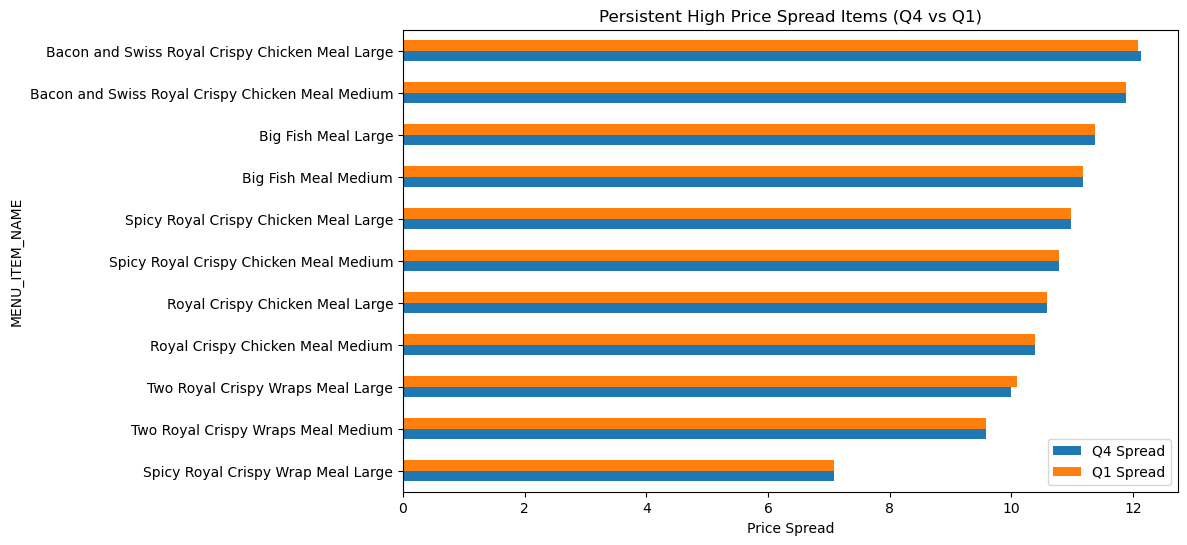

In [37]:
common_items = list(
    set(price_variation_q1.sort_values('diff', ascending=False).head(15).index) &
    set(price_variation_q4.sort_values('diff', ascending=False).head(15).index)
)

compare_df = pd.DataFrame({
    'Q4 Spread': price_variation_q4.loc[common_items, 'diff'],
    'Q1 Spread': price_variation_q1.loc[common_items, 'diff']
}).sort_values('Q1 Spread')

compare_df.plot(kind='barh', figsize=(10,6))

plt.title("Persistent High Price Spread Items (Q4 vs Q1)")
plt.xlabel("Price Spread")

plt.show()


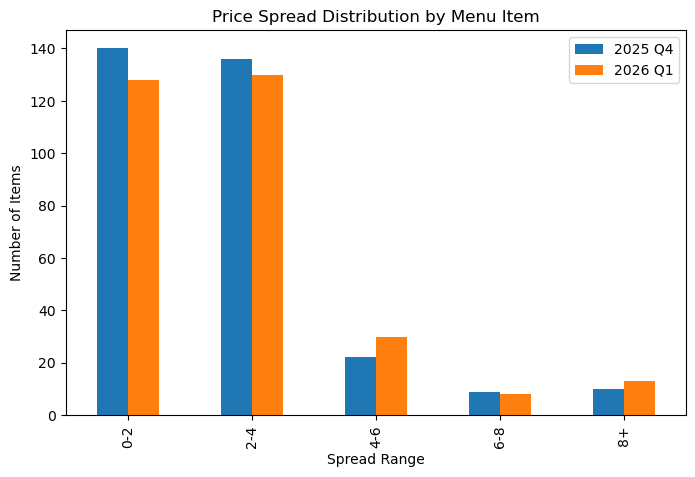

In [38]:
bins = [0,2,4,6,8,12]
labels = ['0-2','2-4','4-6','6-8','8+']

q1_bucket = pd.cut(price_variation_q1['diff'], bins=bins, labels=labels)\
                .value_counts().sort_index()

q4_bucket = pd.cut(price_variation_q4['diff'], bins=bins, labels=labels)\
                .value_counts().sort_index()

bucket_df = pd.DataFrame({
    '2025 Q4': q4_bucket,
    '2026 Q1': q1_bucket
})

bucket_df.plot(kind='bar', figsize=(8,5))

plt.title("Price Spread Distribution by Menu Item")
plt.xlabel("Spread Range")
plt.ylabel("Number of Items")

plt.show()


### Are expensive items actually giving more value?
Price increases with calories, showing fair pricing. Cheap items offer slightly better value, but the small difference across tiers indicates a balanced pricing strategy.

In [39]:
value_df = df[
    ~((df['MENU_SECTION'] == 'Drinks & Coffee') | (df['MENU_SECTION'] == 'NEEDED FOR PAR') & (df['CALORIES'] == 0))
].copy()

In [40]:
value_df = value_df[['MENU_ITEM_NAME','CALORIES','MENU_PRICE']]

In [41]:
value_df = value_df.drop_duplicates()

In [42]:
value_df['calories_per_money'] = (
    value_df['CALORIES'] / value_df['MENU_PRICE']
)

value_df = value_df.groupby('MENU_ITEM_NAME')[['CALORIES','MENU_PRICE','calories_per_money']].median()

In [43]:
value_df['price_tier'] = pd.qcut(
    value_df['MENU_PRICE'],
    q=4,
    labels=['Cheap', 'Mid', 'Expensive','Luxury']
)

In [44]:
value_summary = value_df.groupby('price_tier')['calories_per_money'].median()

print(value_summary)

price_tier
Cheap        142.895029
Mid          124.582777
Expensive    131.138250
Luxury       133.872208
Name: calories_per_money, dtype: float64


In [45]:
worth_item =  value_df.sort_values( 'calories_per_money',ascending = False).head(10)

worth_item

,CALORIES,MENU_PRICE,calories_per_money,price_tier
MENU_ITEM_NAME,,,,
Bacon Cheddar Hash WhopperÂ® Meal Medium,1800.0,0.860,2093.023256,Cheap
Bacon Cheddar Hash WhopperÂ® Jr. Meal Medium,1340.0,0.860,1558.139535,Cheap
Bacon Cheddar Hash WhopperÂ® Meal Large,2080.0,1.595,1308.717949,Cheap
Spicy Flame-Grilled Chicken Sandwich Meal Medium,1250.0,0.990,1262.626263,Cheap
Bacon and Swiss Flame-Grilled Chicken Sandwich Meal Medium,1240.0,0.990,1252.525253,Cheap
Bacon Swiss Club Original Chicken Sandwich Meal Medium,1210.0,0.990,1222.222222,Cheap
SpongeBobâ€™s Krabby WhopperÂ® Meal Medium,1150.0,0.995,1155.808081,Cheap
Flame-Grilled Chicken Sandwich Meal Medium,1090.0,0.990,1101.010101,Cheap
Bacon Cheddar Hash WhopperÂ® Jr. Meal Large,1620.0,1.595,1019.289941,Cheap


In [46]:
worst_item =  value_df.sort_values('calories_per_money').head(10)

worst_item

,CALORIES,MENU_PRICE,calories_per_money,price_tier
MENU_ITEM_NAME,,,,
Trick or Treat Bucket,0.0,2.000,0.000000,Cheap
Value Sprite Zero,5.0,1.560,3.206314,Cheap
Mott'sÂ® Applesauce,50.0,1.675,29.927816,Cheap
8 Pc. Chicken Fries,220.0,4.990,44.088176,Mid
Chicken Fries,220.0,4.990,44.088176,Mid
4 Pc. Chicken Fries,110.0,2.150,51.162791,Cheap
Mr. Krabsâ€™ Cheesy Bacon Tots,130.0,2.390,55.960808,Cheap
Cheesy Bacon Tots,130.0,2.390,55.960808,Cheap
Small Frozen Pink Lemonade,100.0,1.690,59.171598,Cheap


In [47]:
correlation = value_df[['MENU_PRICE','CALORIES']].corr()

correlation

,MENU_PRICE,CALORIES
MENU_PRICE,1.000000,0.881138
CALORIES,0.881138,1.000000


In [48]:
df.head(3)

,STORE_ID,CITY,STATE,ZIP,MENU_SECTION,MENU_ITEM_NAME,MENU_ITEM_DESCRIPTION,CALORIES,MENU_PRICE,QUARTER,Month
0,13165,Houston,TX,77039,Condiments,Zesty Dipping Sauce,None,150,0.25,2025Q4,November
1,13165,Houston,TX,77039,Breakfast Digital Exclusives,Get Going Trio,"Burrito Jr, Small Hot Coffee, and 3Pc French T...",760,5.00,2025Q4,November
2,13165,Houston,TX,77039,Drinks & Coffee,Chocolate OreoÂ® Shake,"Creamy, vanilla soft serve mixed with OREOÂ® c...",670,0.85,2025Q4,November


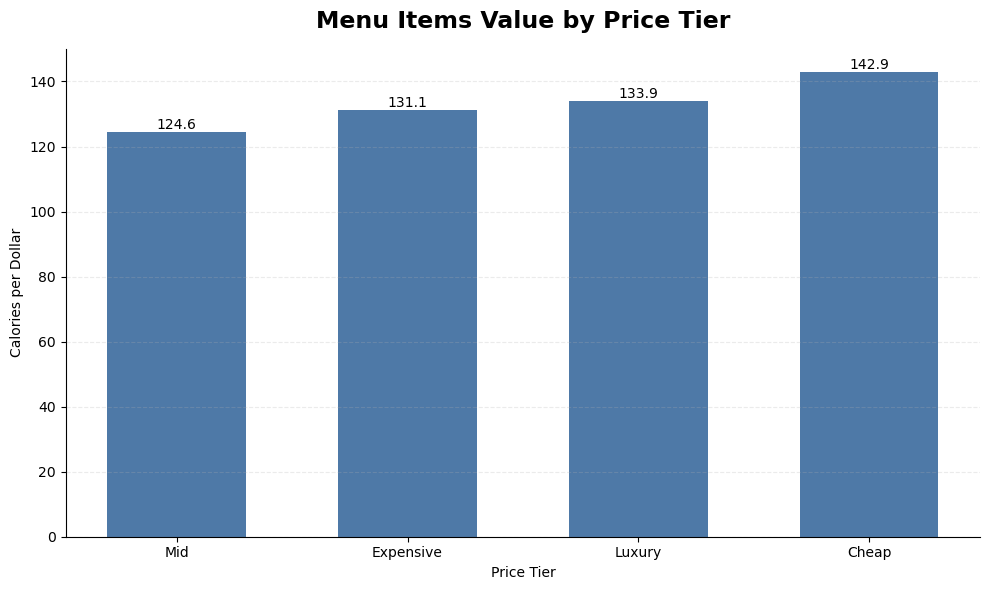

In [49]:
fig, ax = plt.subplots(figsize=(10,6))

data = value_summary.sort_values()

bars = ax.bar(
    data.index,
    data.values,
    color='#4E79A7',
    width=0.6
)

# Clean style
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.25)

ax.set_title(
    "Menu Items Value by Price Tier",
    fontsize=17,
    weight='bold',
    pad=15
)

ax.set_xlabel("Price Tier")
ax.set_ylabel("Calories per Dollar")


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


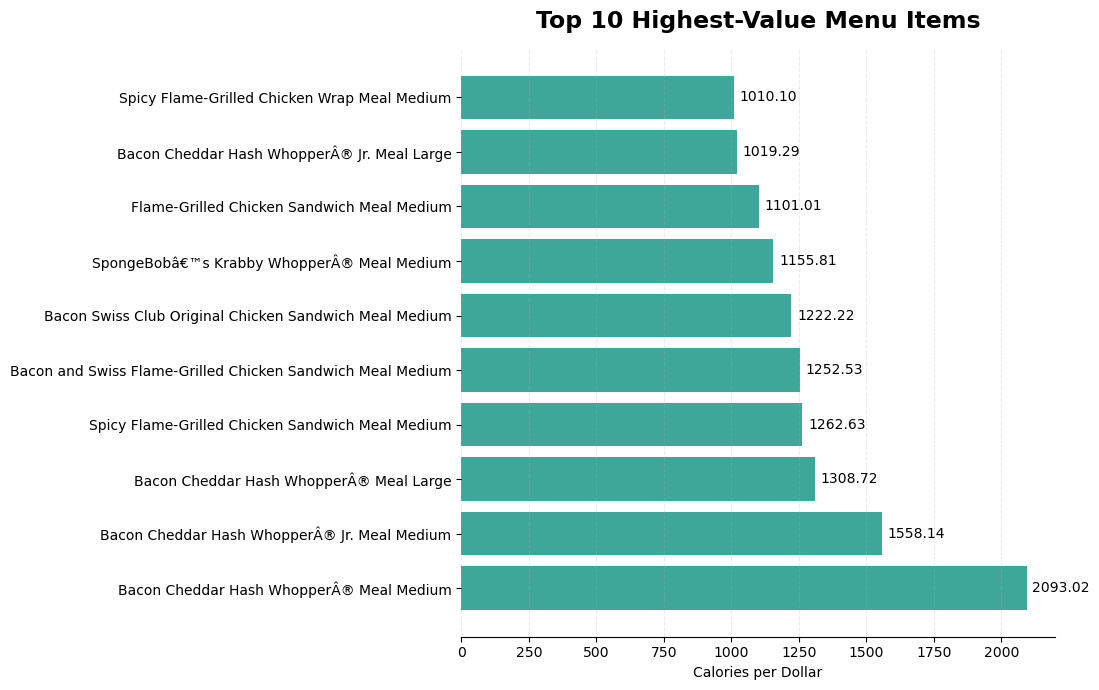

In [50]:
fig, ax = plt.subplots(figsize=(11,7))

data = worth_item.sort_values(by='calories_per_money')

bars = ax.barh(
    data.index,
    data['calories_per_money'],
    color='#2A9D8F',        
    edgecolor='none',
    alpha=0.9
)

ax.invert_yaxis()


for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.25)

ax.set_title(
    "Top 10 Highest-Value Menu Items",
    fontsize=17,
    weight='bold',
    pad=15
)

ax.set_xlabel("Calories per Dollar")

# Value labels
offset = data['calories_per_money'].max() * 0.01

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()


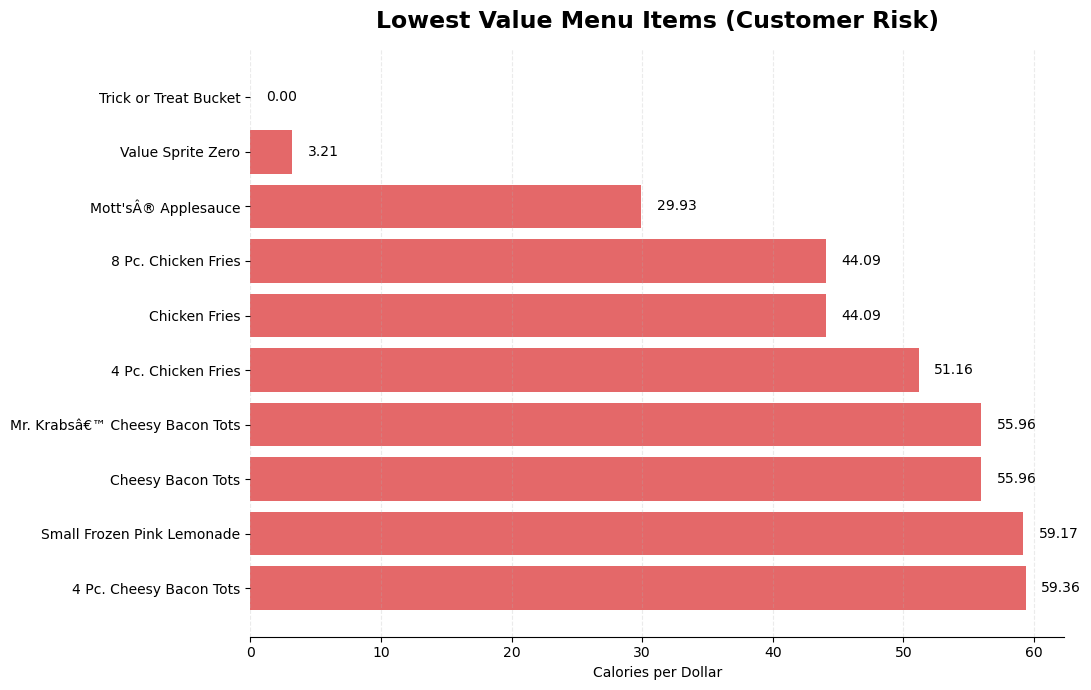

In [51]:
fig, ax = plt.subplots(figsize=(11,7))

data = worst_item.sort_values(by='calories_per_money')

colors = ['#E15759'] * len(data)     
colors[0] = '#B22222'                

bars = ax.barh(
    data.index,
    data['calories_per_money'],
    color=colors,
    alpha=0.9
)

ax.invert_yaxis()

# Remove clutter
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.25)

ax.set_title(
    "Lowest Value Menu Items (Customer Risk)",
    fontsize=17,
    weight='bold',
    pad=15
)

ax.set_xlabel("Calories per Dollar")

# Value labels
offset = data['calories_per_money'].max() * 0.02

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()
